<a href="https://colab.research.google.com/github/aburkov/theDRLbook/blob/main/dqn_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Q-Network (DQN) for PlatformLander

This notebook implements the Chapter 7 DQN algorithm on the discrete-action `PlatformLander`. It follows the same environment setup, randomized starts, training-history plots, and greedy rendered evaluation used by the discrete REINFORCE notebook, while replacing the policy-gradient update with a Q-network, uniform experience replay, a frozen target network, and epsilon-greedy exploration.

The default hyperparameters are the best combination found by the repository's DQN search and confirmed across five seeds. Training is intentionally long; use fewer episodes for a quick classroom run.

In [1]:
# Colab setup. Run this cell first.
!command -v swig >/dev/null || (apt-get -qq update > /dev/null && apt-get -qq install -y swig > /dev/null)
!python -m pip install --no-cache-dir platform_lander==0.1.17 torch pandas matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.5/374.5 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.8-cp312-cp312-linux_x86_64.whl size=2381959 sha256=b2a653664e9c5ad5cd46dd202add774e746325224d3d4ac528f96159058fc9eb
  Stored in directory: /tmp/pip-ephem-wheel-cache-wwcoaddw/wheels/d6/3c/ab/b6fd75459cadc56f4a4125d4cb387a708a59ca8589e4cc6b7d
Successfully built box2d-py


In [2]:
import csv
import math
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F

from platform_lander import PlatformLander
from platform_lander.platform_lander import (
    BOOSTER_BOTTOM,
    BOOSTER_START_CLEARANCE,
    SCALE,
    apply_booster_initial_impulse,
    sample_booster_start_angle,
)

RUNS_DIR = Path('/content/runs') if Path('/content').exists() else Path('runs')
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# Best DQN combination found by search_dqn_hyperparams.py.
EPISODES = 3_000
MAX_STEPS = 400
GAMMA = 0.99
LEARNING_RATE = 3e-4
HIDDEN_DIM = 64
BUFFER_CAPACITY = 50_000
BATCH_SIZE = 256
LEARNING_STARTS = 5_000
TARGET_SYNC_EVERY = 1_000
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 100_000
SEED = 0
TARGET_WINDOW = 50
PRINT_EVERY = 250
RANDOM_BOOSTER_START_X = False

ENABLE_WIND = True
WIND_POWER = 3.0
SUCCESS_REWARD = 1000.0
FAILURE_REWARD = -300.0
SHAPING_FACTOR = 1.0
MAX_JET_FIRES = 50

MODEL_FILE = RUNS_DIR / 'dqn.pt'
BEST_MODEL_FILE = RUNS_DIR / 'dqn_best.pt'
CSV_FILE = RUNS_DIR / 'dqn.csv'


def environment_kwargs(render_mode=None):
    return {
        'render_mode': render_mode,
        'enable_wind': ENABLE_WIND,
        'wind_power': WIND_POWER,
        'wind_direction': (1.0, 0.0),
        'success_reward': SUCCESS_REWARD,
        'failure_reward': FAILURE_REWARD,
        'shaping_factor': SHAPING_FACTOR,
        'max_jet_fires': MAX_JET_FIRES,
    }

## Platform Lander

The environment contains a reusable booster falling toward a horizontally moving ocean platform. Its discrete action space has four actions:

```text
0: do nothing
1: fire the upper-left attitude jet
2: fire the bottom engine
3: fire the upper-right attitude jet
```

The observation is an 11-dimensional vector containing relative position, velocity, angle, angular velocity, landing-foot contacts, platform position and velocity, and remaining engine budget. DQN applies because all four actions can be enumerated: one network pass produces all four action values.

![](https://raw.githubusercontent.com/aburkov/theDRLbook/main/test_environments/platform_lander/booster_landing_stages.png)

In [3]:
env = PlatformLander(**environment_kwargs())
observation, info = env.reset(seed=SEED)
print('observation_space:', env.observation_space)
print('action_space:', env.action_space)
print('initial observation shape:', observation.shape)
print('initial observation:', np.round(observation, 3))
env.close()

observation_space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
   0.          0.         -1.         -2.          0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.         1.         2.         1.       ], (11,), float32)
action_space: Discrete(4)
initial observation shape: (11,)
initial observation: [ 0.     1.474 -0.416  0.147  0.032  0.     0.     0.    -0.358  0.383
  1.   ]


## Q-network

The network follows the discrete REINFORCE architecture: two 64-unit `Tanh` hidden layers with orthogonal initialization. Its output layer has one scalar per action. These are action-value estimates, not policy logits.

In [4]:
def init_layer(layer, gain=math.sqrt(2.0), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, gain=gain)
    nn.init.constant_(layer.bias, bias_const)
    return layer


class QNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim, hid_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            init_layer(nn.Linear(obs_dim, hid_dim)),
            nn.Tanh(),
            init_layer(nn.Linear(hid_dim, hid_dim)),
            nn.Tanh(),
            init_layer(nn.Linear(hid_dim, act_dim)),  # one Q-value per action
        )

    def forward(self, obs):
        return self.net(obs)

## Experience replay

The replay buffer is a circular collection of recent transitions `(observation, action, reward, next_observation, done)`. Uniform random minibatches break temporal correlation and let each transition teach the network more than once.

In [5]:
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, rng):
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)
        self.capacity = capacity
        self.rng = rng
        self.position = 0
        self.size = 0

    def store(self, obs, action, reward, next_obs, done):
        i = self.position
        self.obs[i] = obs
        self.actions[i] = action
        self.rewards[i] = reward
        self.next_obs[i] = next_obs
        self.dones[i] = float(done)
        self.position = (self.position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        indices = self.rng.integers(0, self.size, size=batch_size)
        return (
            torch.as_tensor(self.obs[indices]),
            torch.as_tensor(self.actions[indices]),
            torch.as_tensor(self.rewards[indices]),
            torch.as_tensor(self.next_obs[indices]),
            torch.as_tensor(self.dones[indices]),
        )

## Epsilon-greedy behavior

During training, epsilon decreases linearly from 1.0 to 0.05 over 100,000 environment steps. Evaluation uses epsilon zero and therefore always selects the action with the largest predicted value.

In [6]:
def epsilon_at(step):
    fraction = min(step / EPS_DECAY_STEPS, 1.0)
    return EPS_START + fraction * (EPS_END - EPS_START)


def select_action(q_network, obs, epsilon, rng, act_dim):
    if rng.random() < epsilon:
        return int(rng.integers(act_dim))
    with torch.no_grad():
        q_values = q_network(torch.as_tensor(obs, dtype=torch.float32))
    return int(torch.argmax(q_values).item())

## Randomized episode starts

This is the same start randomization as the discrete REINFORCE notebook: platform position and direction, booster angle, initial impulse, and environment seed all vary from episode to episode.

In [7]:
def randomize_start(env, rng, random_booster_start_x=False):
    assert env.booster is not None and env.platform is not None
    h = 400 / 30.0
    env.platform.position = (float(rng.uniform(env.platform_min_x, env.platform_max_x)), env.platform_y)
    env.platform_direction = int(rng.choice([-1, 1]))
    env.platform.linearVelocity = (env.platform_speed * env.platform_direction, 0.0)
    booster_x = (
        float(rng.uniform(env.platform_min_x, env.platform_max_x))
        if random_booster_start_x else float(env.platform.position.x)
    )
    env.booster.position = (booster_x, float(h + BOOSTER_BOTTOM / SCALE + BOOSTER_START_CLEARANCE))
    env.booster.angle = sample_booster_start_angle(rng)
    env.booster.linearVelocity = (0.0, 0.0)
    env.booster.angularVelocity = 0.0
    apply_booster_initial_impulse(env.booster, rng)
    env.booster.awake = True
    env.ocean_contact = False
    env.platform_contact = False
    env.body_platform_contact = False
    env.left_foot_contact = False
    env.right_foot_contact = False
    env.failure_reason = None
    env.prev_shaping = None
    env.bottom_flame_power = 0.0
    env.top_flame_power = 0.0
    env.top_flame_direction = 0
    env.jet_fires_used = 0.0
    return env._get_state()

## The DQN update

`gather` selects the predicted Q-value of each stored action. The target network supplies the next-observation maximum. Multiplying by `1 - done` prevents bootstrapping past a terminal transition. The target network is synchronized every 1,000 environment steps.

In [8]:
def update_q_network(q_network, target_network, optimizer, replay_buffer):
    obs_b, act_b, rew_b, next_obs_b, done_b = replay_buffer.sample(BATCH_SIZE)
    q_selected = q_network(obs_b).gather(1, act_b.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q = target_network(next_obs_b).max(dim=1).values
        targets = rew_b + GAMMA * (1.0 - done_b) * next_q
    loss = F.mse_loss(q_selected, targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return float(loss.detach().item())

## Training

One transition is stored and one minibatch update is performed per environment step after the 5,000-transition warm-up. The best checkpoint is replaced whenever the trailing 50-episode landing count improves. Training stops after the first perfect 50/50 streak, matching the comparison protocol.

In [9]:
def save_checkpoint(q_network, path, obs_dim, act_dim, episode, environment_steps):
    torch.save({
        'q_network_state_dict': q_network.state_dict(),
        'obs_dim': obs_dim,
        'action_dim': act_dim,
        'hidden_dim': HIDDEN_DIM,
        'episode': episode,
        'environment_steps': environment_steps,
    }, path)


def train():
    torch.manual_seed(SEED)
    rng = np.random.default_rng(SEED)
    env = PlatformLander(**environment_kwargs())
    obs_dim = int(env.observation_space.shape[0])
    act_dim = int(env.action_space.n)
    q_network = QNetwork(obs_dim, act_dim, HIDDEN_DIM)
    target_network = QNetwork(obs_dim, act_dim, HIDDEN_DIM)
    target_network.load_state_dict(q_network.state_dict())
    optimizer = torch.optim.Adam(q_network.parameters(), lr=LEARNING_RATE)
    replay_buffer = ReplayBuffer(BUFFER_CAPACITY, obs_dim, rng)
    recent_returns = deque(maxlen=TARGET_WINDOW)
    recent_successes = deque(maxlen=TARGET_WINDOW)
    history = []
    environment_steps = 0
    best_success50 = -1

    try:
        for episode in range(1, EPISODES + 1):
            observation, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
            observation = randomize_start(env, rng, RANDOM_BOOSTER_START_X)
            rewards, losses = [], []
            info = {}

            for step_index in range(MAX_STEPS):
                epsilon = epsilon_at(environment_steps)
                action = select_action(q_network, observation, epsilon, rng, act_dim)
                next_observation, reward, terminated, truncated, info = env.step(action)
                timeout = step_index + 1 == MAX_STEPS and not (terminated or truncated)
                done = terminated or truncated or timeout
                if timeout:
                    reward = FAILURE_REWARD
                    info = {**info, 'success': False, 'failure_reason': 'timeout'}
                replay_buffer.store(observation, action, float(reward), next_observation, done)
                rewards.append(float(reward))
                observation = next_observation
                environment_steps += 1

                if replay_buffer.size >= LEARNING_STARTS:
                    losses.append(update_q_network(q_network, target_network, optimizer, replay_buffer))
                if environment_steps % TARGET_SYNC_EVERY == 0:
                    target_network.load_state_dict(q_network.state_dict())
                if done:
                    break

            episode_return = sum((GAMMA ** t) * reward for t, reward in enumerate(rewards))
            success = bool(info.get('success', False))
            recent_returns.append(episode_return)
            recent_successes.append(success)
            success_count = int(sum(recent_successes))
            row = {
                'episode': episode,
                'environment_steps': environment_steps,
                'return': episode_return,
                'average_return': float(np.mean(recent_returns)),
                'success': success,
                'success_count': success_count,
                'success_rate': success_count / len(recent_successes),
                'epsilon': epsilon_at(environment_steps),
                'loss': float(np.mean(losses)) if losses else np.nan,
            }
            history.append(row)

            full_window = len(recent_successes) == TARGET_WINDOW
            if full_window and success_count > best_success50:
                best_success50 = success_count
                save_checkpoint(q_network, BEST_MODEL_FILE, obs_dim, act_dim, episode, environment_steps)
            if episode == 1 or episode % PRINT_EVERY == 0:
                print(
                    f"episode={episode:5d} steps={environment_steps:8d} "
                    f"avg50={row['average_return']:8.2f} success50={success_count:2d} "
                    f"epsilon={row['epsilon']:.3f}"
                )
            if full_window and success_count == TARGET_WINDOW:
                print(f'first 50/50 streak at episode {episode}')
                break
    finally:
        env.close()

    save_checkpoint(q_network, MODEL_FILE, obs_dim, act_dim, episode, environment_steps)
    history = pd.DataFrame(history)
    history.to_csv(CSV_FILE, index=False)
    return q_network, history


q_network, history = train()
history.tail()

episode=    1 steps=     324 avg50= -493.55 success50= 0 epsilon=0.997
episode=  250 steps=   54559 avg50= -189.75 success50= 0 epsilon=0.482
episode=  500 steps=  122499 avg50=   21.33 success50= 1 epsilon=0.050
episode=  750 steps=  172751 avg50=  146.35 success50=31 epsilon=0.050
episode= 1000 steps=  217962 avg50=  203.61 success50=38 epsilon=0.050
episode= 1250 steps=  260988 avg50=  208.56 success50=35 epsilon=0.050
episode= 1500 steps=  290931 avg50=  257.13 success50=45 epsilon=0.050
episode= 1750 steps=  318230 avg50=  309.11 success50=49 epsilon=0.050
episode= 2000 steps=  345466 avg50=  275.23 success50=43 epsilon=0.050
first 50/50 streak at episode 2043


,episode,environment_steps,return,average_return,success,success_count,success_rate,epsilon,loss
2038,2039,349481,263.901587,300.777320,True,48,0.96,0.05,210.845447
2039,2040,349569,387.508092,306.781371,True,49,0.98,0.05,199.081291
2040,2041,349666,330.438338,307.496363,True,49,0.98,0.05,219.198535
2041,2042,349755,345.724670,308.456792,True,49,0.98,0.05,172.654037
2042,2043,349851,352.006148,314.787023,True,50,1.00,0.05,205.571105


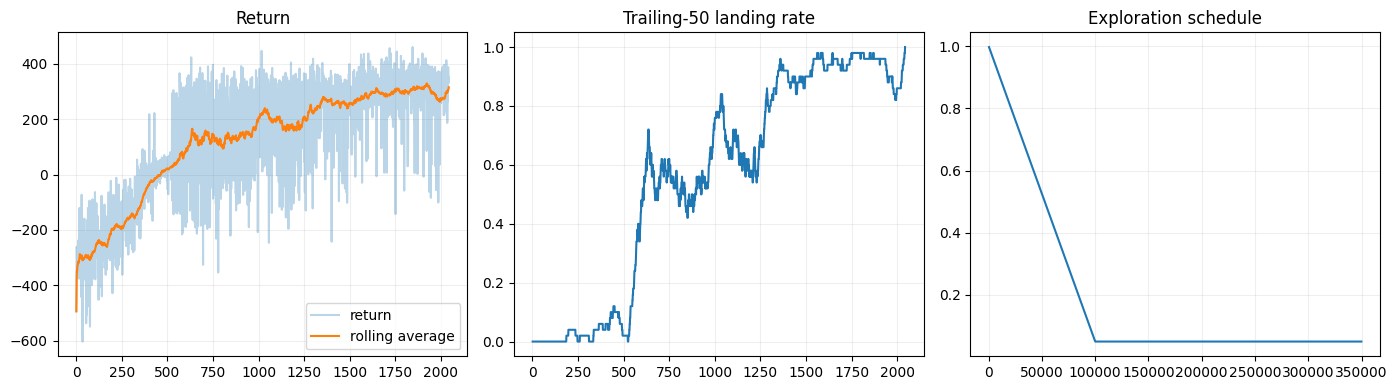

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history['episode'], history['return'], alpha=0.3, label='return')
axes[0].plot(history['episode'], history['average_return'], label='rolling average')
axes[0].set_title('Return')
axes[0].legend()
axes[1].plot(history['episode'], history['success_rate'])
axes[1].set_title('Trailing-50 landing rate')
axes[1].set_ylim(-0.05, 1.05)
axes[2].plot(history['environment_steps'], history['epsilon'])
axes[2].set_title('Exploration schedule')
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Greedy evaluation and animation

Evaluation sets epsilon to zero. The cell loads the best trailing-window checkpoint, evaluates 100 fresh randomized episodes, and reports the safe landing rate. The final cell renders one episode as an inline animation.

In [11]:
def load_q_network(path):
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    network = QNetwork(checkpoint['obs_dim'], checkpoint['action_dim'], checkpoint['hidden_dim'])
    network.load_state_dict(checkpoint['q_network_state_dict'])
    network.eval()
    return network


def evaluate(q_network, episodes=100, seed=SEED + 1_000_000):
    rng = np.random.default_rng(seed)
    env = PlatformLander(**environment_kwargs())
    successes = 0
    try:
        for _ in range(episodes):
            observation, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
            observation = randomize_start(env, rng, RANDOM_BOOSTER_START_X)
            info = {}
            for _ in range(MAX_STEPS):
                action = select_action(q_network, observation, 0.0, rng, int(env.action_space.n))
                observation, reward, terminated, truncated, info = env.step(action)
                if terminated or truncated:
                    break
            successes += int(bool(info.get('success', False)))
    finally:
        env.close()
    return successes / episodes


best_q_network = load_q_network(BEST_MODEL_FILE)
print(f'greedy safe landing rate: {evaluate(best_q_network):.1%}')

greedy safe landing rate: 98.0%


In [12]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation


def rollout_frames(q_network, seed=SEED + 2_000_000):
    rng = np.random.default_rng(seed)
    env = PlatformLander(**environment_kwargs(render_mode='rgb_array'))
    frames = []
    try:
        observation, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
        observation = randomize_start(env, rng, RANDOM_BOOSTER_START_X)
        for _ in range(MAX_STEPS):
            action = select_action(q_network, observation, 0.0, rng, int(env.action_space.n))
            observation, reward, terminated, truncated, info = env.step(action)
            frames.append(env.render())
            if terminated or truncated:
                break
    finally:
        env.close()
    return frames


frames = rollout_frames(best_q_network)
fig, ax = plt.subplots(figsize=(7, 4.7))
image = ax.imshow(frames[0])
ax.axis('off')

def draw(index):
    image.set_data(frames[index])
    return (image,)

animation = FuncAnimation(fig, draw, frames=len(frames), interval=20, blit=True)
plt.close(fig)
HTML(animation.to_jshtml())

pygame 2.6.1 (SDL 2.28.4, Python 3.12.13)
Hello from the pygame community. https://www.pygame.org/contribute.html
